In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# Load Dataset
data = pd.read_csv("Mall_Customers.csv")

In [5]:
# Select Features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

In [6]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


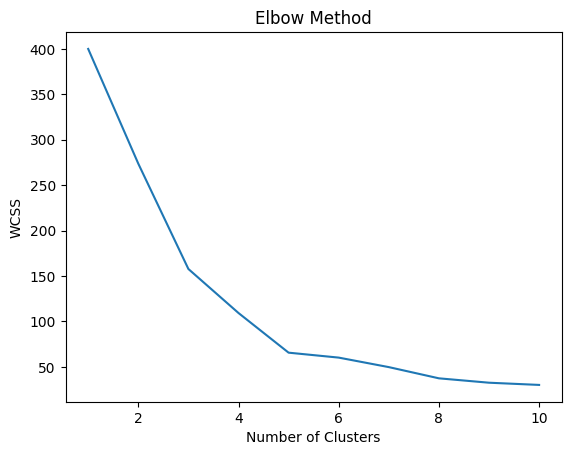

In [8]:
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [9]:
# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

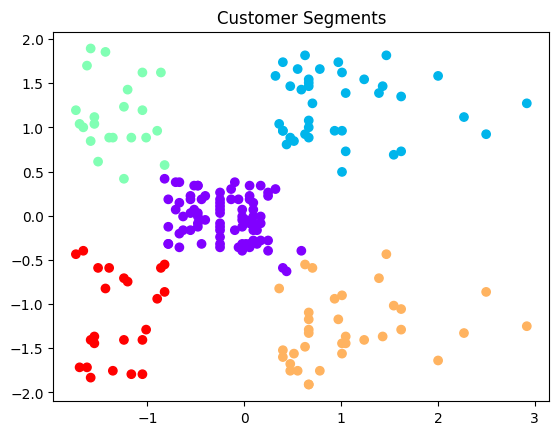

In [10]:
# Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=data['Cluster'], cmap='rainbow')
plt.title("Customer Segments")
plt.show()